In [1]:
#install test

import torch
x = torch.rand(5, 3)
print(x)


tensor([[0.1331, 0.6793, 0.3376],
        [0.4775, 0.3225, 0.6568],
        [0.0033, 0.9063, 0.5837],
        [0.1168, 0.1581, 0.3684],
        [0.6264, 0.0793, 0.6039]])


In [1]:
import os
import glob
import shutil

# torchaudio 2.11's load() delegates to TorchCodec, which needs FFmpeg's shared
# DLLs (avcodec-*.dll, avutil-*.dll, ...) on the Windows DLL search path. PATH
# isn't searched for a DLL's dependencies on Python 3.8+, so expose the ffmpeg
# bin folder explicitly *before* importing torchaudio. Note: a folder may hold
# ffmpeg.exe yet lack the shared DLLs (e.g. Chocolatey's shim), so we only
# accept a directory that actually contains avcodec-*.dll.
def _expose_ffmpeg_dlls():
    candidates = []
    found = shutil.which("ffmpeg")
    if found:
        candidates.append(os.path.dirname(found))
    candidates.append(
        r"C:\Users\phyju\AppData\Local\ffmpeg-shared\ffmpeg-master-latest-win64-gpl-shared\bin"
    )
    for d in candidates:
        if d and glob.glob(os.path.join(d, "avcodec-*.dll")):
            os.add_dll_directory(d)
            return d
    raise RuntimeError("Could not find an ffmpeg bin directory containing shared DLLs")

print("Using ffmpeg DLLs from:", _expose_ffmpeg_dlls())

import torch
import torchaudio
import requests
import matplotlib.pyplot as plt

Using ffmpeg DLLs from: C:\Users\phyju\AppData\Local\ffmpeg-shared\ffmpeg-master-latest-win64-gpl-shared\bin


Shape of waveform: torch.Size([2, 276858])
Sample rate of waveform: 44100


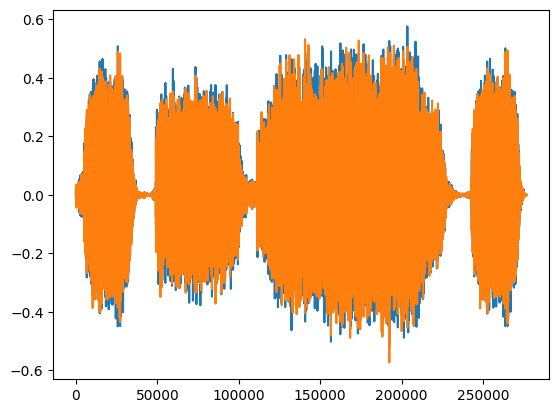

In [2]:
import torch
import torchaudio
import requests
import matplotlib.pyplot as plt

url = "https://pytorch.org/tutorials/_static/img/steam-train-whistle-daniel_simon-converted-from-mp3.wav"
r = requests.get(url)

with open('steam-train-whistle-daniel_simon-converted-from-mp3.wav', 'wb') as f:
    f.write(r.content)

filename = "steam-train-whistle-daniel_simon-converted-from-mp3.wav"
waveform, sample_rate = torchaudio.load(filename)

print("Shape of waveform: {}".format(waveform.size()))
print("Sample rate of waveform: {}".format(sample_rate))

plt.figure()
plt.plot(waveform.t().numpy())
